In [1]:
from torchvision import datasets
import torch
import torchvision.transforms as T
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
import torchinfo

In [2]:
torch.backends.cudnn.benchmark = True

In [3]:
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])
transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])
train_ds = datasets.CIFAR10("./data", train=True, transform=transform_train, download=True)
test_ds = datasets.CIFAR10("./data", train=False, transform=transform_test, download=True)

d:\projects\Supervised-Learning-Experiments\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, padding=1, kernel_size=3)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, padding=1, kernel_size=3)
        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, padding=1, kernel_size=3)
        self.conv4 = nn.Conv2d(in_channels=256, out_channels=512, padding=1, kernel_size=3)
        self.pool2 = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(512, 1024)
        self.fc2 = nn.Linear(1024, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        # print(x.shape)
        x = self.conv1(x)
        x = torch.relu(x)
        # print(x.shape)
        x = self.pool1(x)
        # print(x.shape)
        x = self.conv2(x)
        x = torch.relu(x)
        # print(x.shape)
        x = self.pool1(x)
        # print(x.shape)
        x = self.conv3(x)
        x = torch.relu(x)
        x = self.conv4(x)
        # print(x.shape)
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        # print(x.shape)
        x = self.fc1(x)
        x = torch.relu(x)
        # print(x.shape)
        x = self.fc2(x)
        x = torch.relu(x)
        x = self.fc3(x)
        return x

### Training Function

This function handles the training loop. It includes:
- Device management (moving data/model to GPU/CPU)
- A learning rate scheduler (StepLR)
- Tracking of training and testing metrics (loss, accuracy)
- Model checkpointing (saving the best weights based on validation accuracy)
- Plotting of the learning curves at the end

In [5]:
from torch import optim

import torch
import copy
import torch.nn.functional as F
import matplotlib.pyplot as plt

def train(model, train_loader, test_loader, optimizer, epochs, criterion):
    """
    Trains a PyTorch model, evaluates it on a test set, and plots the results.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device, non_blocking=True)
    
    # Decay LR by a factor of 0.1 every 7 epochs
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    train_losses = []
    test_losses = []
    test_accuracies = []  # List to store accuracy for each epoch
    best_accuracy = 0  # Best accuracy found
    best_model_wts = copy.deepcopy(model.state_dict())


    # Main training loop
    for epoch in range(epochs):
        # Training phase
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            # Clear gradients from previous step
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            # Backpropagate to compute gradients
            loss.backward()
            # Update weights
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()  # Update the learning rate

        train_losses.append(total_loss / len(train_loader))


        # Validation phase
        model.eval()
        total_test_loss = 0
        correct = 0
        total = 0
        # Disable gradient computation for evaluation
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_test_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_loss = total_test_loss / len(test_loader)
        epoch_accuracy = correct / total
        test_losses.append(epoch_loss)
        test_accuracies.append(epoch_accuracy)


        # Checkpoint the best model
        if epoch_accuracy > best_accuracy:
            best_accuracy = epoch_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_losses[-1]}, Testing Loss: {test_losses[-1]}, Testing Accuracy: {epoch_accuracy:.4f}")

    # Load best model weights
    # Restore best weights
    model.load_state_dict(best_model_wts)
    print(f"Loaded the best model from epoch {best_epoch} with Testing Accuracy: {best_accuracy:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
    plt.plot(range(1, epochs+1), test_losses, label='Testing Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs+1), test_accuracies, label='Testing Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

    return # train_losses, test_losses, test_accuracies, best_accuracy

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
batch_size = 256
epochs = 10


cuda


In [7]:
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)
model = Net().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [8]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
Net                                      --
├─Conv2d: 1-1                            1,792
├─MaxPool2d: 1-2                         --
├─Conv2d: 1-3                            73,856
├─Conv2d: 1-4                            295,168
├─Conv2d: 1-5                            1,180,160
├─AdaptiveAvgPool2d: 1-6                 --
├─Linear: 1-7                            525,312
├─Linear: 1-8                            131,200
├─Linear: 1-9                            1,290
Total params: 2,208,778
Trainable params: 2,208,778
Non-trainable params: 0

Epoch 1/10, Training Loss: 0.6397688866269832, Testing Loss: 0.7144158154726028, Testing Accuracy: 0.7495
Epoch 2/10, Training Loss: 0.6383043983761145, Testing Loss: 0.7127306059002876, Testing Accuracy: 0.7493
Epoch 3/10, Training Loss: 0.6383535162526734, Testing Loss: 0.7123299807310104, Testing Accuracy: 0.7495
Epoch 4/10, Training Loss: 0.639423034781096, Testing Loss: 0.712649604678154, Testing Accuracy: 0.7495
Epoch 5/10, Training Loss: 0.6384782917341407, Testing Loss: 0.711244697868824, Testing Accuracy: 0.7499
Epoch 6/10, Training Loss: 0.6359856627425369, Testing Loss: 0.7107843235135078, Testing Accuracy: 0.7499
Epoch 7/10, Training Loss: 0.6338881024596642, Testing Loss: 0.7108444705605507, Testing Accuracy: 0.7507
Epoch 8/10, Training Loss: 0.6313507191988886, Testing Loss: 0.7070702955126762, Testing Accuracy: 0.7531
Epoch 9/10, Training Loss: 0.6302689541967548, Testing Loss: 0.706852351129055, Testing Accuracy: 0.7525
Epoch 10/10, Training Loss: 0.6294345490786494, Te

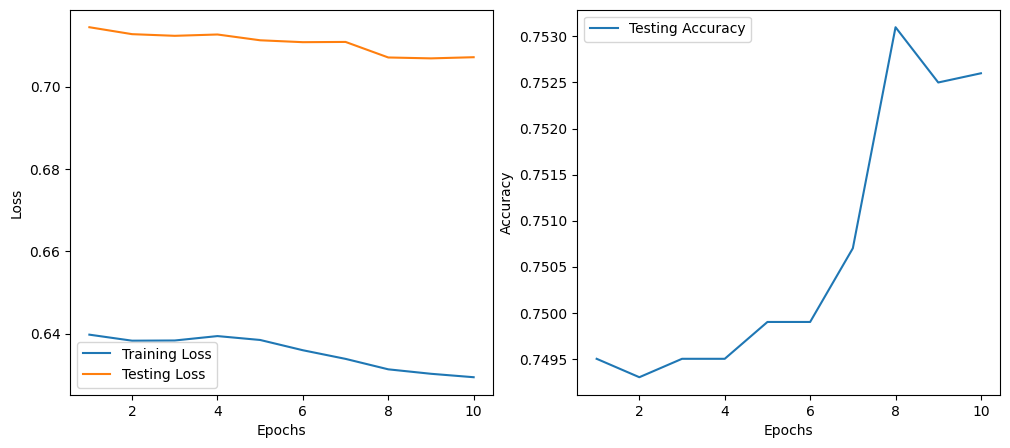

In [11]:
train(model, train_loader, test_loader, optimizer, epochs, criterion)